#  Proyecto 1: Regresión Lineal

Nombre: Francico Gonzalez

Carnet: 24002914

## -- Parte 1: Preparación y Exploración --

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder,
    StandardScaler, KBinsDiscretizer
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
# Carga del dataset
df = pd.read_csv('dataset_proyecto_regresion.csv', parse_dates=['RegistrationDate'])
display(df.sample(15))


,ID,RegistrationDate,Age,AnnualIncome,EducationLevel,Gender,MaritalStatus,Children,Employed,JobTitle,...,CommuteDistance,CreditScore,Debt,Savings,OwnsHouse,InternetUsage,HasPet,FitnessLevel,EnvironmentalAwareness,TargetSpend
1154,1155,2016-02-25,56.0,40132.48,Bachelor,Female,Widowed,1,Yes,Teacher,...,19.04,581.241676,13293.61,36944.31,Yes,0.54,No,5,1,5692.73
1163,1164,2017-01-25,NaN,35774.78,High School,Male,Married,1,Yes,Artist,...,6.10,690.528507,25567.84,11824.97,Yes,4.25,Yes,1,4,6246.24
1359,1360,2019-01-21,41.0,52911.61,High School,Male,Single,2,Yes,Engineer,...,26.22,708.067546,2720.27,15876.06,Yes,2.35,Yes,3,1,6889.77
1325,1326,2016-03-04,20.0,75561.58,High School,Female,Divorced,1,Yes,Teacher,...,7.93,642.620406,5386.14,18345.71,No,4.04,Yes,3,4,13145.68
600,601,2017-03-28,47.0,55646.14,High School,Male,Single,1,Yes,Doctor,...,20.02,665.127970,21688.00,13941.28,Yes,2.68,Yes,4,5,4433.69
816,817,2018-01-29,42.0,62584.11,Bachelor,Male,Divorced,2,Yes,Lawyer,...,20.47,628.844528,32286.65,28874.00,No,5.45,No,4,3,7342.70
1096,1097,2021-03-17,40.0,40899.50,High School,Male,Single,1,Yes,Doctor,...,9.64,671.519468,19504.91,5471.12,No,1.72,Yes,3,5,8953.12
291,292,2015-08-30,35.0,51725.39,PhD,Other,NaN,0,Yes,Other,...,24.52,617.327566,18696.81,12072.77,Yes,2.37,No,3,3,9455.10
81,82,2023-09-02,43.0,67229.56,High School,Male,Widowed,2,NaN,Teacher,...,16.76,679.642783,15920.77,25681.45,Yes,2.00,Yes,3,3,7806.12
1358,1359,2020-10-24,25.0,67695.88,Bachelor,Female,Divorced,3,NaN,Other,...,16.18,601.259997,18507.65,33548.68,No,0.68,Yes,3,2,6096.38


In [3]:
# EDA básica
display(df.info())
display(df.describe())
print("Valores faltantes por columna:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID                      1500 non-null   int64         
 1   RegistrationDate        1500 non-null   datetime64[ns]
 2   Age                     1455 non-null   float64       
 3   AnnualIncome            1455 non-null   float64       
 4   EducationLevel          1475 non-null   object        
 5   Gender                  1468 non-null   object        
 6   MaritalStatus           1195 non-null   object        
 7   Children                1500 non-null   int64         
 8   Employed                1404 non-null   object        
 9   JobTitle                1500 non-null   object        
 10  HoursPerWeek            1500 non-null   float64       
 11  CommuteDistance         1500 non-null   float64       
 12  CreditScore             1455 non-null   float64 

None

,ID,RegistrationDate,Age,AnnualIncome,Children,HoursPerWeek,CommuteDistance,CreditScore,Debt,Savings,InternetUsage,FitnessLevel,EnvironmentalAwareness,TargetSpend
count,1500.000000,1500,1455.000000,1455.000000,1500.000000,1500.000000,1500.000000,1455.000000,1455.000000,1455.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,2020-01-15 01:33:07.200000,40.009622,51548.917718,1.494000,40.050612,15.503853,649.798640,15335.685725,20602.341381,3.158667,3.024000,2.992667,6814.397767
min,1.000000,2015-01-02 00:00:00,7.000000,4707.320000,0.000000,11.833914,0.050000,493.152779,-10937.250000,-14198.150000,0.010000,1.000000,1.000000,746.810000
25%,375.750000,2017-08-14 00:00:00,33.000000,40543.690000,1.000000,33.190972,8.390000,616.782737,9602.395000,13107.380000,1.630000,2.000000,2.000000,5193.037500
50%,750.500000,2020-01-28 00:00:00,40.000000,50102.000000,1.000000,39.763680,15.180000,649.062297,15338.450000,19500.540000,3.090000,3.000000,3.000000,6641.840000
75%,1125.250000,2022-07-06 00:00:00,46.000000,60288.700000,2.000000,47.052864,21.230000,683.522707,20367.640000,26934.335000,4.540000,4.000000,4.000000,8301.012500
max,1500.000000,2024-12-25 00:00:00,78.000000,334407.610000,7.000000,70.290930,48.180000,812.141604,127087.240000,178241.640000,9.230000,5.000000,5.000000,16247.830000
std,433.157015,NaN,9.899907,21847.060740,1.177096,10.180397,8.993387,49.211296,9378.492010,13356.128958,1.826823,1.087603,1.428977,2400.672717


Valores faltantes por columna:
 ID                          0
RegistrationDate            0
Age                        45
AnnualIncome               45
EducationLevel             25
Gender                     32
MaritalStatus             305
Children                    0
Employed                   96
JobTitle                    0
HoursPerWeek                0
CommuteDistance             0
CreditScore                45
Debt                       45
Savings                    45
OwnsHouse                  74
InternetUsage               0
HasPet                      0
FitnessLevel                0
EnvironmentalAwareness      0
TargetSpend                 0
dtype: int64


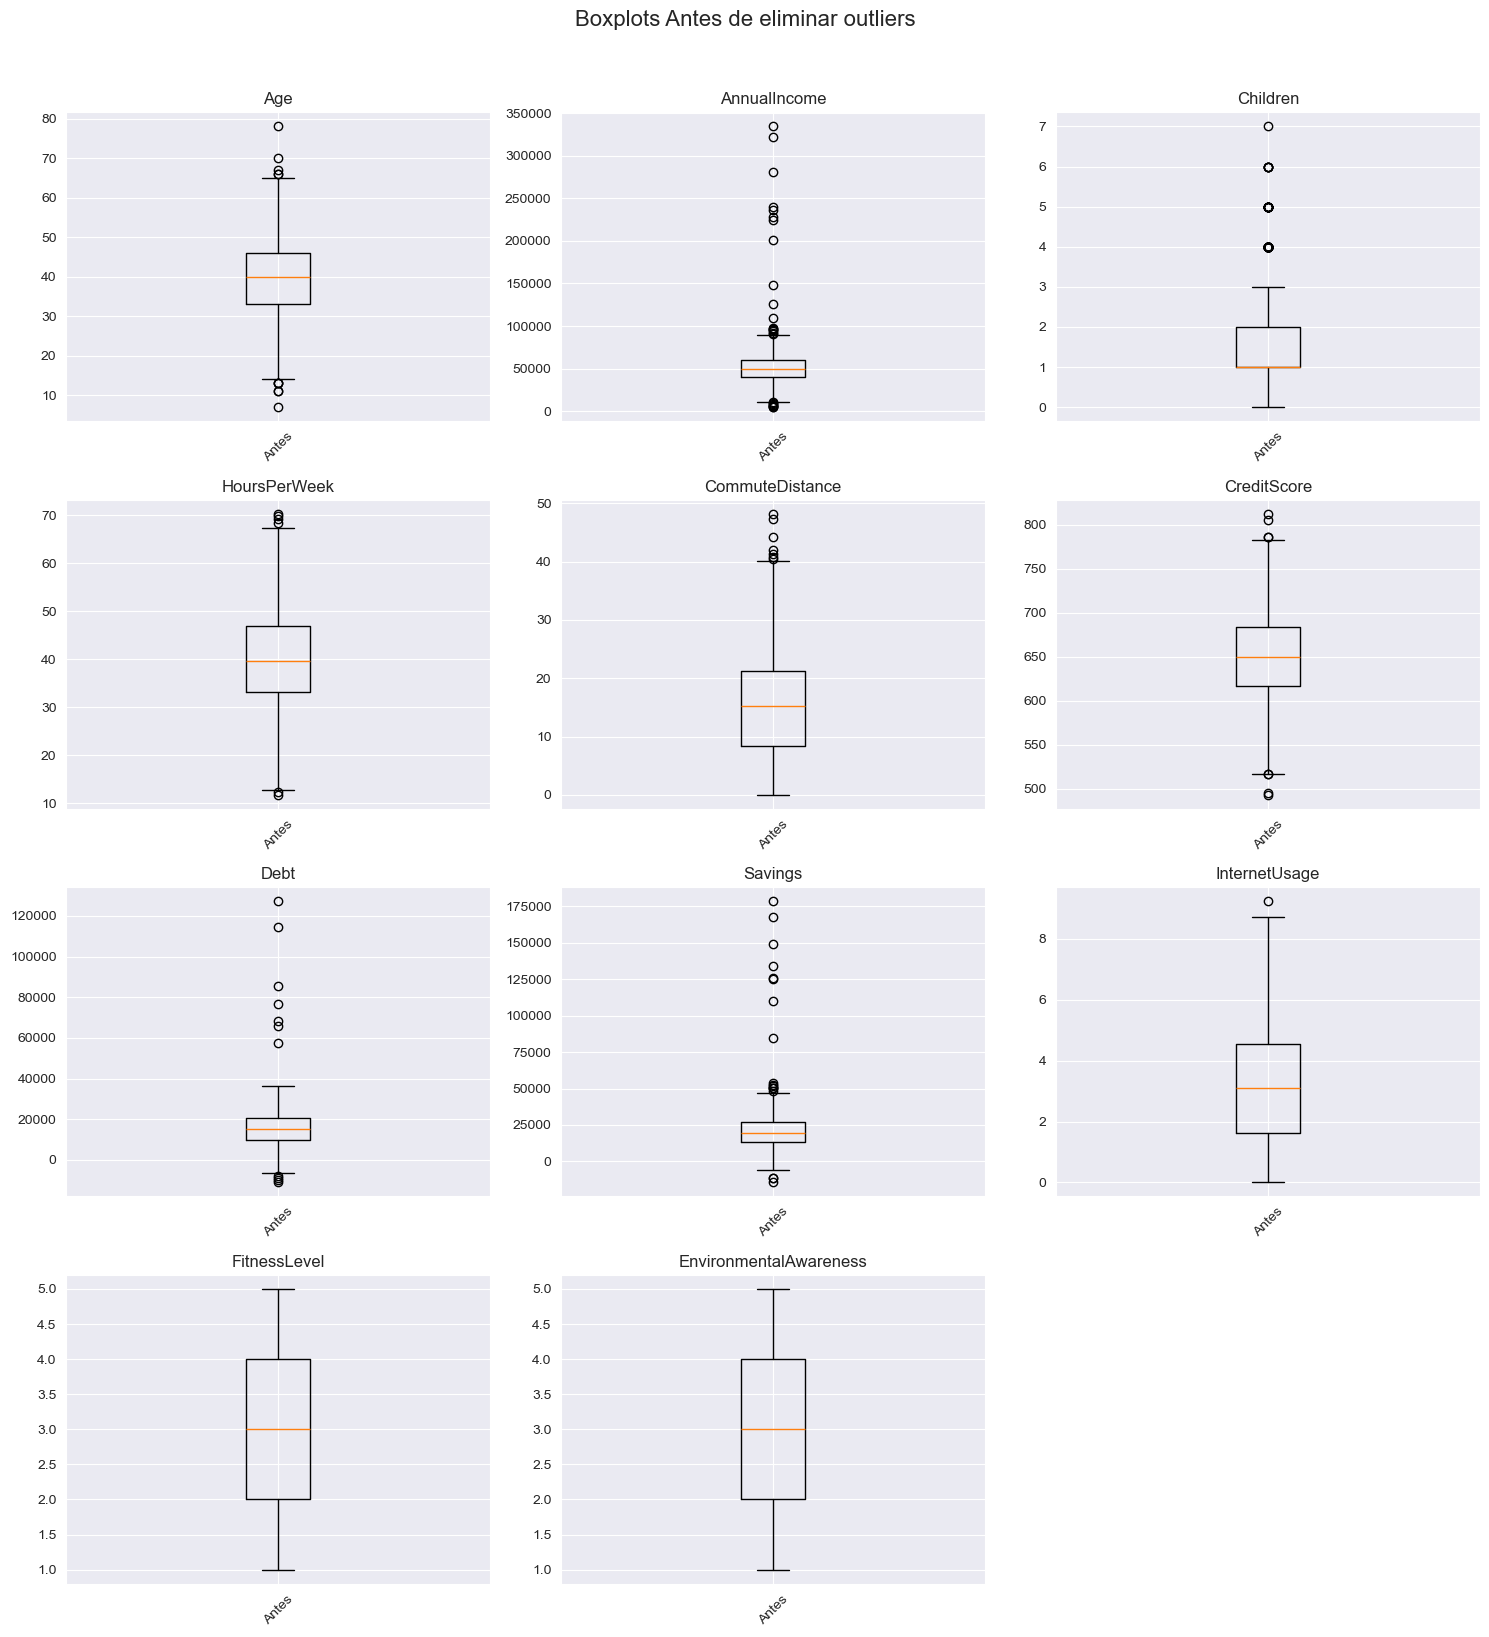

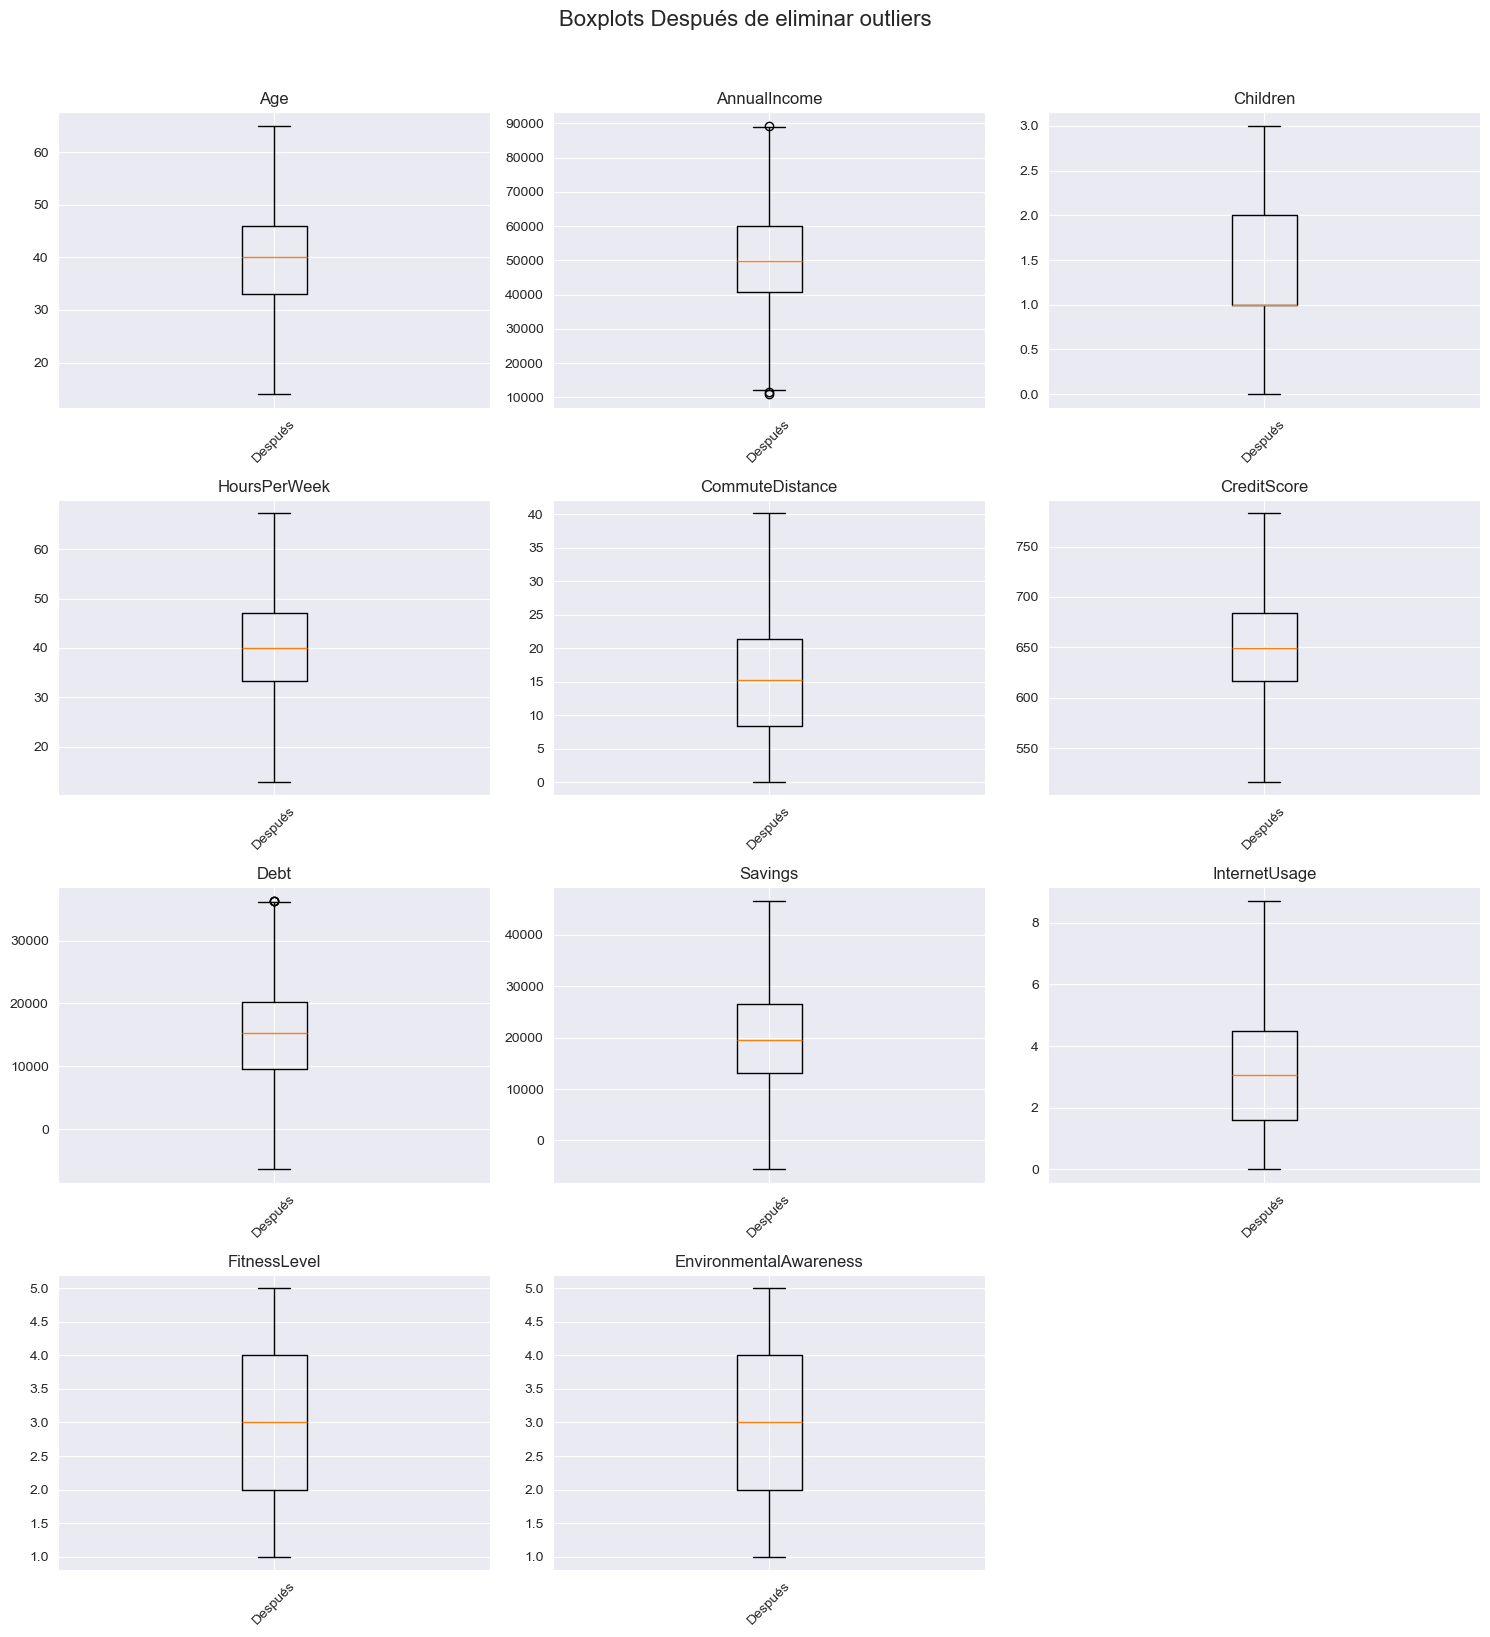

In [4]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(['ID', 'TargetSpend'])

# 2) Guardar una copia antes de eliminar outliers
df_before = df.copy()

# 3) Calcular IQR y detectar outliers
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
mask_outliers = (
    (df[num_cols] < (Q1 - 1.5 * IQR)) |
    (df[num_cols] > (Q3 + 1.5 * IQR))
).any(axis=1)

# 4) Crear el DataFrame sin outliers
df_after = df.loc[~mask_outliers].copy()

# 5) Definir la cuadrícula de subplots
n = len(num_cols)
ncols = 3
nrows = math.ceil(n / ncols)

# 6) Boxplots "Antes"
fig1, axes1 = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
axes1 = axes1.flatten()

for idx, col in enumerate(num_cols):
    axes1[idx].boxplot([df_before[col].dropna()], tick_labels=['Antes'])
    axes1[idx].set_title(col)
    axes1[idx].tick_params(axis='x', rotation=45)

# Eliminar ejes vacíos
for j in range(idx + 1, len(axes1)):
    fig1.delaxes(axes1[j])

fig1.suptitle('Boxplots Antes de eliminar outliers', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# 7) Boxplots "Después"
fig2, axes2 = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
axes2 = axes2.flatten()

for idx, col in enumerate(num_cols):
    axes2[idx].boxplot([df_after[col].dropna()], tick_labels=['Después'])
    axes2[idx].set_title(col)
    axes2[idx].tick_params(axis='x', rotation=45)

# Eliminar ejes vacíos
for j in range(idx + 1, len(axes2)):
    fig2.delaxes(axes2[j])

fig2.suptitle('Boxplots Después de eliminar outliers', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

df= df_after.copy()  # Actualizar df con los datos sin outliers


In [5]:
# Conversión de fechas: crear YearsSinceRegistration
df['YearsSinceRegistration'] = ((pd.Timestamp('today') - df['RegistrationDate']).dt.days) / 365.25

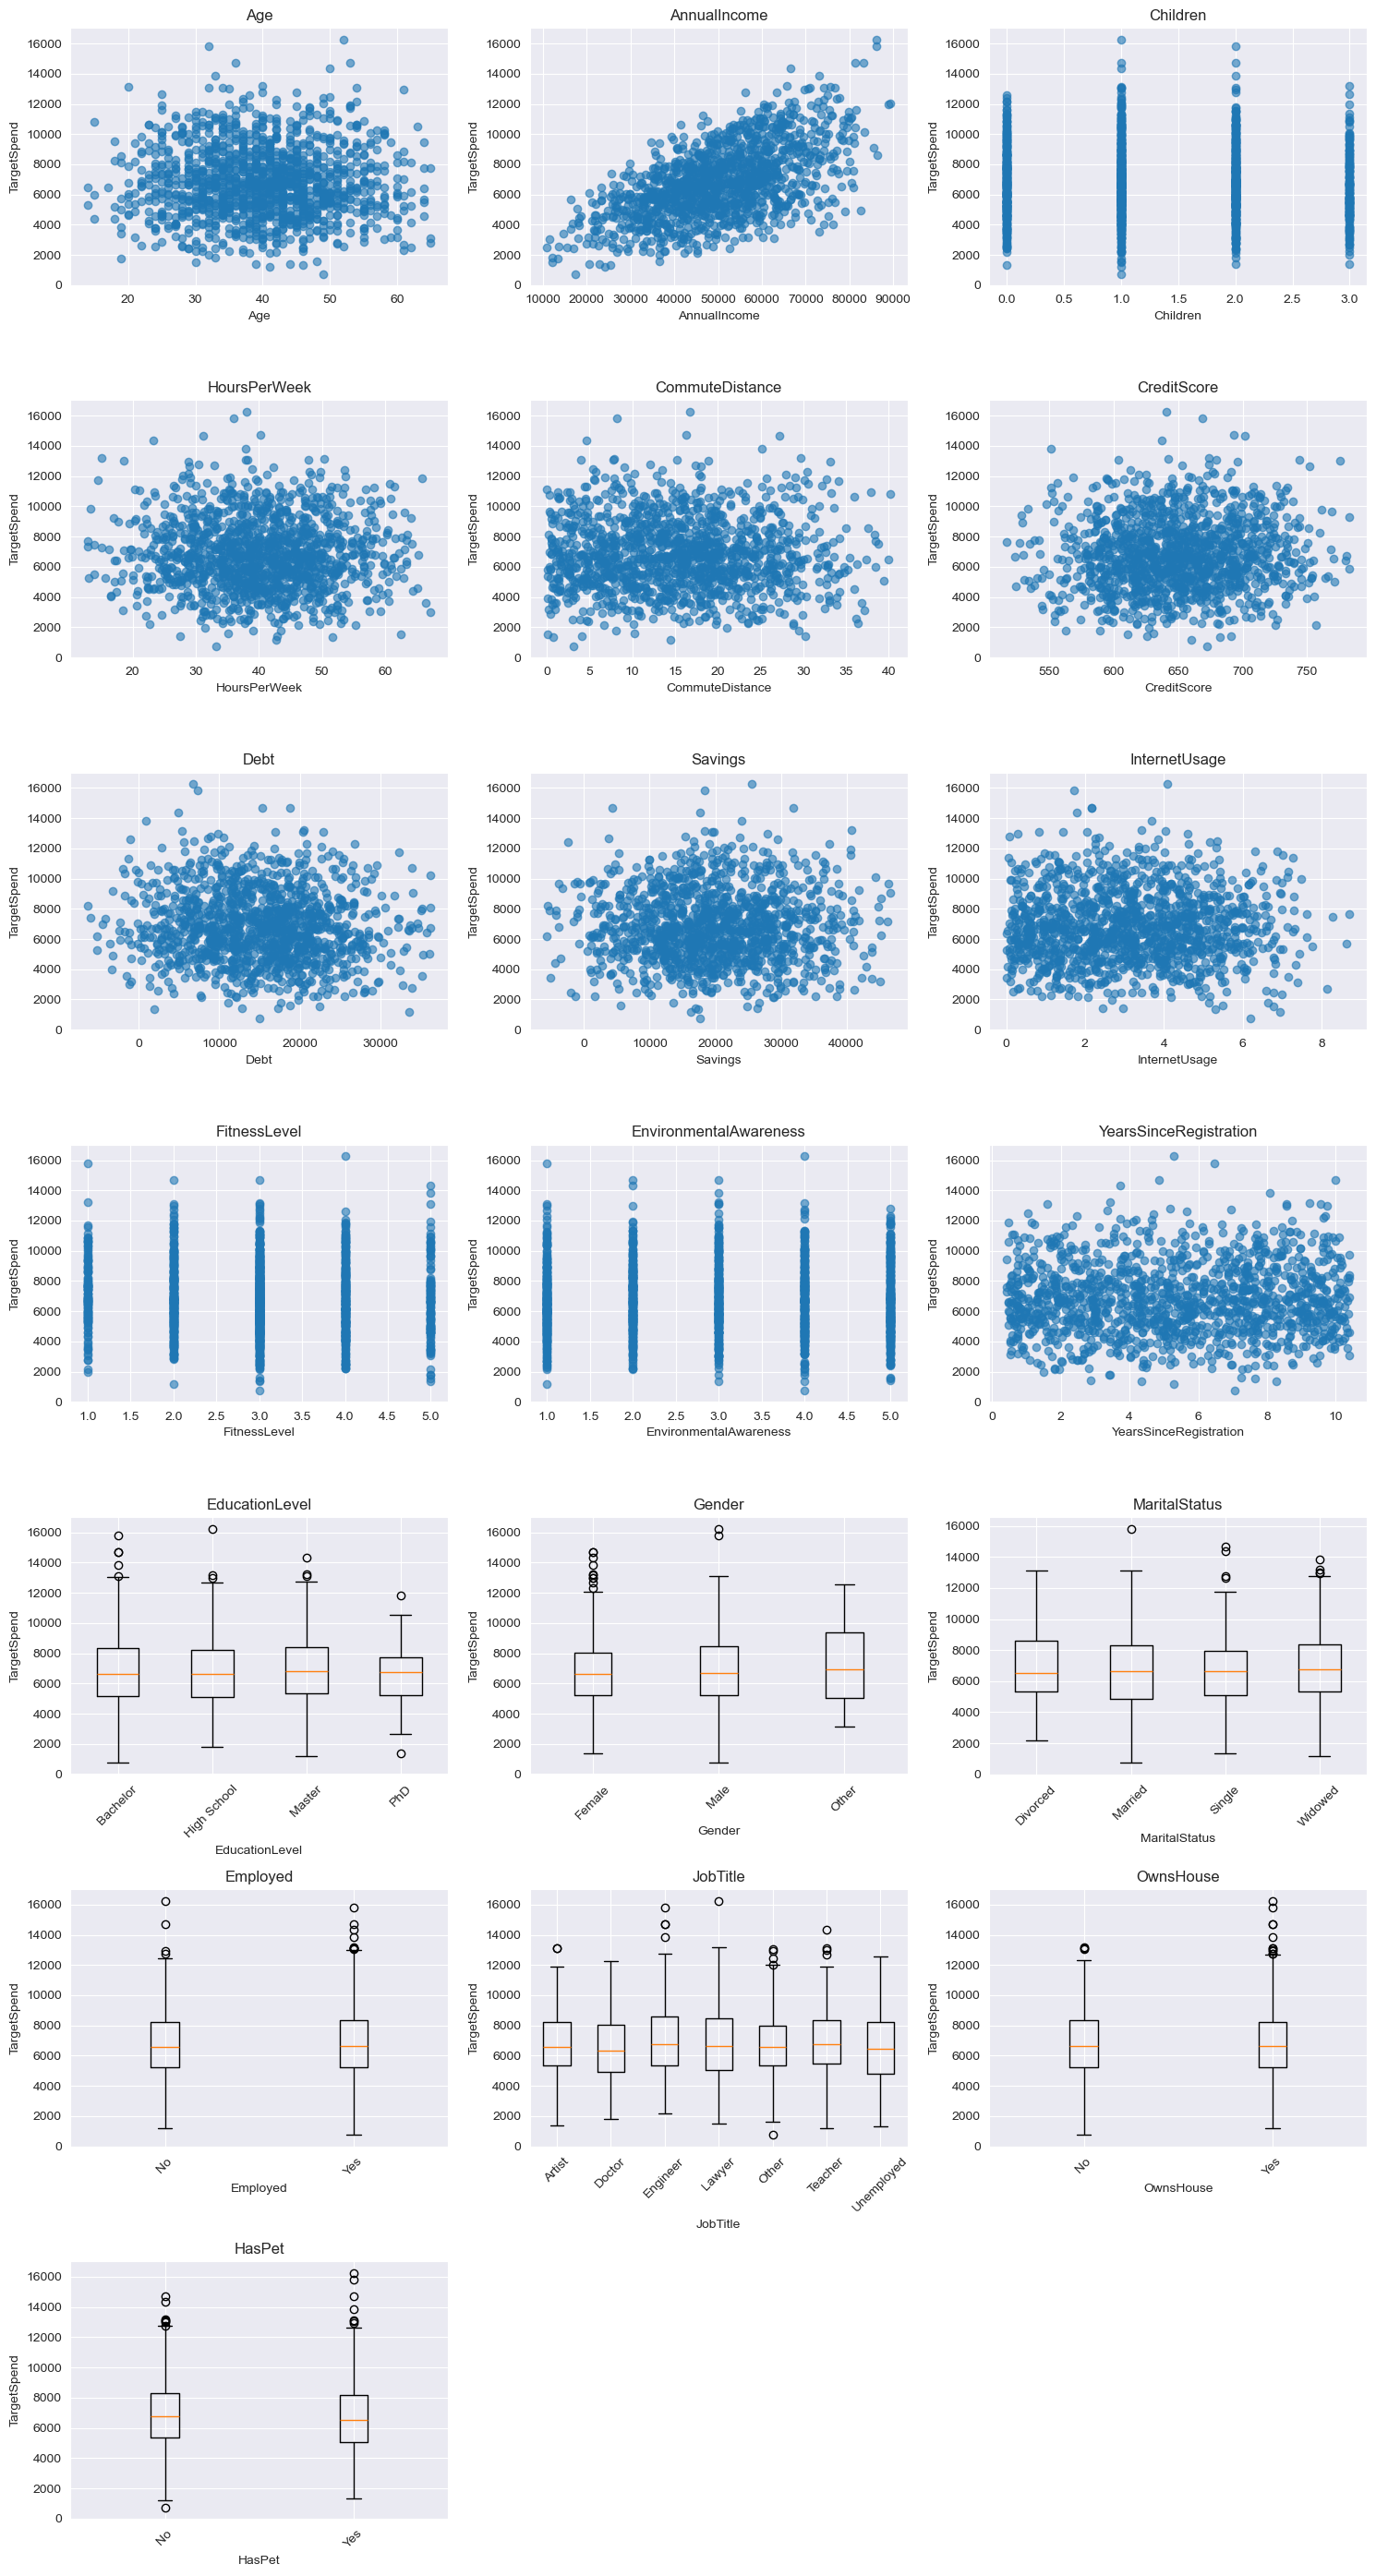

In [6]:
# 2) Definir variables a graficar (excluyendo ID, TargetSpend y fecha)
features = df.columns.drop(['ID', 'TargetSpend', 'RegistrationDate'])

# 3) Separar numéricas y categóricas
numeric_feats = df[features].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_feats = df[features].select_dtypes(include=['object', 'category']).columns.tolist()
all_feats = numeric_feats + categorical_feats

# 4) Configurar la cuadrícula de subplots
n = len(all_feats)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

# 5) Dibujar cada gráfico según tipo de variable
for idx, feat in enumerate(all_feats):
    ax = axes[idx]
    if feat in numeric_feats:
        # Scatter plot para variables numéricas
        ax.scatter(df[feat], df['TargetSpend'], alpha=0.6)
        ax.set_xlabel(feat)
        ax.set_ylabel('TargetSpend')
    else:
        # Boxplot de TargetSpend para cada categoría
        groups = df.groupby(feat)['TargetSpend']
        data = [groups.get_group(cat).values for cat in groups.groups]
        ax.boxplot(data, tick_labels=list(groups.groups.keys()))
        ax.set_xlabel(feat)
        ax.set_ylabel('TargetSpend')
        ax.tick_params(axis='x', rotation=45)
    ax.set_title(feat)

# 6) Eliminar ejes vacíos
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



A partir de los gráficos podemos extraer las siguientes conclusiones:

AnnualIncome
– Existe una clara correlación positiva con TargetSpend: a mayor ingreso anual, mayor gasto en el producto/servicio. Es, con diferencia, la relación más fuerte de todas las variables numéricas.

Debt y Savings
– Ambas muestran una ligera tendencia positiva: consumidores con más deuda tienden a gastar un poco más (quizá porque financian compras), y quienes tienen más ahorros también gastan algo más. Pero la dispersión es amplia, así que su poder predictivo es moderado.

CreditScore
– No hay un patrón evidente: aunque el gasto medio se mantiene alrededor de un valor similar para puntajes entre 550–750, la variabilidad es alta y no parece ser un buen predictor directo.

Age, HoursPerWeek, CommuteDistance
– No se aprecia ninguna relación clara con el gasto. Personas de cualquier edad, horas trabajadas o distancia al trabajo pueden gastar tanto bajo como alto.

Children
– Tampoco muestra un patrón definitivo. Hay casos de familias con muchos hijos que gastan poco y otras que gastan mucho; el número de niños no parece influir de forma lineal.

InternetUsage
– Ligera tendencia a que quienes usan más horas de internet diario gasten algo más, pero el efecto es muy tenue.

FitnessLevel y EnvironmentalAwareness
– No se observa ninguna diferencia significativa en el gasto según el nivel de fitness o de conciencia ambiental. Los boxplots están muy solapados.

EducationLevel
– Hay un pequeño ascenso en el gasto medio para niveles “Master” y “PhD” frente a “High School” o “Bachelor”, pero con muchos outliers y solapamiento, así que su influencia es reducida.

Gender, MaritalStatus, Employed, OwnsHouse, HasPet
– Las diferencias de gasto medio entre categorías (hombre/mujer/otro, casado/soltero/divorciado, etc.) son mínimas. Quizá un leve mayor gasto en personas empleadas, propietarios de vivienda o con mascota, pero no es un efecto fuerte ni consistente.

JobTitle
– Algunos roles (por ejemplo, “Doctor” o “Engineer”) tienden a mostrar un gasto medio algo mayor que “Artist” o “Unemployed”, pero de nuevo la variabilidad interna de cada grupo es alta.

Resumen general:
– Financieras (AnnualIncome, Debt, Savings) son las que mejor explican el gasto.
– Demográficas (edad, hijos, género, estado civil…) y comportamentales (horas de internet, fitness, conciencia ambiental…) apenas aportan señal clara.
– Es muy probable que un modelo lineal se beneficie principalmente de las variables de ingreso/ahorro/deuda, y que necesitemos ingeniería de características o variables adicionales (por ejemplo, interacciones o datos de comportamiento más finos) para mejorar la predicción con el resto de los atributos.

A partir de los gráficos podemos extraer las siguientes conclusiones:

AnnualIncome
– Existe una clara correlación positiva con TargetSpend: a mayor ingreso anual, mayor gasto en el producto/servicio. Es, con diferencia, la relación más fuerte de todas las variables numéricas.

Debt y Savings
– Ambas muestran una ligera tendencia positiva: consumidores con más deuda tienden a gastar un poco más (quizá porque financian compras), y quienes tienen más ahorros también gastan algo más. Pero la dispersión es amplia, así que su poder predictivo es moderado.

CreditScore
– No hay un patrón evidente: aunque el gasto medio se mantiene alrededor de un valor similar para puntajes entre 550–750, la variabilidad es alta y no parece ser un buen predictor directo.

Age, HoursPerWeek, CommuteDistance
– No se aprecia ninguna relación clara con el gasto. Personas de cualquier edad, horas trabajadas o distancia al trabajo pueden gastar tanto bajo como alto.

Children
– Tampoco muestra un patrón definitivo. Hay casos de familias con muchos hijos que gastan poco y otras que gastan mucho; el número de niños no parece influir de forma lineal.

InternetUsage
– Ligera tendencia a que quienes usan más horas de internet diario gasten algo más, pero el efecto es muy tenue.

FitnessLevel y EnvironmentalAwareness
– No se observa ninguna diferencia significativa en el gasto según el nivel de fitness o de conciencia ambiental. Los boxplots están muy solapados.

EducationLevel
– Hay un pequeño ascenso en el gasto medio para niveles “Master” y “PhD” frente a “High School” o “Bachelor”, pero con muchos outliers y solapamiento, así que su influencia es reducida.

Gender, MaritalStatus, Employed, OwnsHouse, HasPet
– Las diferencias de gasto medio entre categorías (hombre/mujer/otro, casado/soltero/divorciado, etc.) son mínimas. Quizá un leve mayor gasto en personas empleadas, propietarios de vivienda o con mascota, pero no es un efecto fuerte ni consistente.

JobTitle
– Algunos roles (por ejemplo, “Doctor” o “Engineer”) tienden a mostrar un gasto medio algo mayor que “Artist” o “Unemployed”, pero de nuevo la variabilidad interna de cada grupo es alta.

Resumen general:
– Financieras (AnnualIncome, Debt, Savings) son las que mejor explican el gasto.
– Demográficas (edad, hijos, género, estado civil…) y comportamentales (horas de internet, fitness, conciencia ambiental…) apenas aportan señal clara.
– Es muy probable que un modelo lineal se beneficie principalmente de las variables de ingreso/ahorro/deuda, y que necesitemos ingeniería de características o variables adicionales (por ejemplo, interacciones o datos de comportamiento más finos) para mejorar la predicción con el resto de los atributos.# -- Parte 2: Ingeniería de Características --

## -- Parte 2: Ingeniería de Características --


In [7]:
# Definición de grupos de variables
numeric_feats = ['AnnualIncome','Children','HoursPerWeek','CommuteDistance',
                 'CreditScore','Debt','Savings','InternetUsage','YearsSinceRegistration']
bin_feats     = ['Age','Debt','CreditScore']
ordinal_feats = ['Employed','OwnsHouse','HasPet']
nominal_feats = ['EducationLevel','Gender','MaritalStatus','JobTitle']

In [8]:
# 1) Para variables numéricas continuas:
#    - Imputa valores faltantes con la mediana
#    - Estandariza (media=0, varianza=1)
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # rellenar NaN con la mediana
    ('scaler',  StandardScaler())                    # escalar características
])

# 2) Para variables numéricas que queremos discretizar ("binned"):
#    - Imputa con mediana
#    - Discretiza en 5 grupos iguales según cuantiles
#    - Estandariza los “bins” resultantes
bin_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # rellenar NaN con mediana
    ('kbins',    KBinsDiscretizer(
                     n_bins=5,
                     encode='ordinal',
                     strategy='quantile'
                 )),                              # convertir en categorías ordinales
    ('scaler',   StandardScaler())                  # escalar bins
])

# 3) Para variables ordinales de texto (Sí/No):
#    - Imputa valores faltantes con 'No'
#    - Codifica 'No'→0, 'Yes'→1 para cada columna ordinal
ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='No')),
    ('oe',      OrdinalEncoder(
                    categories=[['No','Yes']] * len(ordinal_feats)
                ))                                          # mapea No/Yes a 0/1
])

# 4) Para variables categóricas nominales:
#    - Imputa valores faltantes con la categoría más frecuente
#    - One-hot encoding (crea columnas binarias, ignora categorías nuevas)
nominal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore'))        # codificación one-hot
])

# 5) Ensamblar todo en un preprocesador:
#    Aplica cada pipeline sólo a sus columnas correspondientes
preprocessor = ColumnTransformer([
    ('num',  numeric_transformer,   numeric_feats),    # continuas
    ('bins', bin_transformer,       bin_feats),        # binned
    ('ord',  ordinal_transformer,   ordinal_feats),    # ordinales
    ('nom',  nominal_transformer,   nominal_feats),    # nominales
])

## -- Parte 3: Modelado --

In [9]:
# Separación de datos
X = df.drop(columns=['ID','TargetSpend'])
y = df['TargetSpend']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# Definición de modelos
models = {
    'LinearRegression': LinearRegression(),
    'Ridge':            Ridge(alpha=1.0),
    'Lasso':            Lasso(alpha=0.1)
}

In [11]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

## -- Parte 4: Evaluación --


In [12]:
# Diccionario para almacenar los resultados de validación cruzada
results = {}

# Itera sobre cada modelo definido en el diccionario `models`
for name, model in models.items():
    # Crea un pipeline que primero aplica el preprocesador y luego ajusta el modelo
    pipe = Pipeline([
        ('prep',  preprocessor),  # Paso de preprocesamiento: imputación, escalado, encoding, etc.
        ('model', model)          # Paso de modelado: LinearRegression, Ridge o Lasso
    ])

    # 1) Ejecuta validación cruzada con 5 particiones (cv=cv)
    #    - scoring='neg_mean_squared_error' devuelve el MSE con signo negativo
    #    - cross_val_score devuelve un array con un valor negativo de MSE por fold
    neg_mse = cross_val_score(
        pipe,            # pipeline completo (preprocesamiento + modelo)
        X_train,         # datos de entrenamiento (características)
        y_train,         # datos de entrenamiento (target)
        scoring='neg_mean_squared_error',
        cv=cv            # esquema de particionado (KFold)
    )

    # 2) Convertir el MSE negativo en RMSE
    #    - Multiplicamos por -1 para obtener MSE positivo
    #    - Aplicamos sqrt() para convertir a RMSE
    #    - Luego obtenemos la media sobre los 5 folds
    rmse = np.sqrt(-neg_mse).mean()

    # 3) Guardar el RMSE de validación cruzada en el diccionario de resultados
    results[name] = {'CV_RMSE': rmse}

    # 4) Mostrar en consola el nombre del modelo y su RMSE medio
    print(f"{name} CV RMSE: {rmse:.2f}")


LinearRegression CV RMSE: 1962.31
Ridge CV RMSE: 1961.78
Lasso CV RMSE: 1962.12


In [13]:
# -------------------------------------------------
# Entrenamiento final de cada modelo y evaluación
# -------------------------------------------------


# Recorre cada modelo definido en `models`
for name, model in models.items():
    # 1) Construye un pipeline que aplica el preprocesador y luego el modelo
    pipe = Pipeline([
        ('prep',  preprocessor),  # preprocesamiento de datos (imputación, escalado, encoding...)
        ('model', model)          # modelo de regresión (Linear, Ridge, Lasso)
    ])

    # 2) Ajusta (entrena) el pipeline completo con los datos de entrenamiento
    pipe.fit(X_train, y_train)

    # 3) Genera predicciones sobre el conjunto de prueba
    y_pred = pipe.predict(X_test)

    # 4) Calcula las métricas de evaluación:
    #    - R²: proporción de varianza explicada
    r2 = r2_score(y_test, y_pred)
    #    - MSE: error cuadrático medio
    mse = mean_squared_error(y_test, y_pred)
    #    - RMSE: raíz del MSE (misma unidad que la variable objetivo)
    rmse = np.sqrt(mse)
    #    - MAE: error absoluto medio
    mae = mean_absolute_error(y_test, y_pred)

    # 5) Actualiza el diccionario `results` con las métricas de test
    results[name].update({
        'R2':  r2,
        'RMSE': rmse,
        'MAE': mae
    })

    # 6) Muestra los resultados en consola
    print(f"\n{name} Test R2:   {r2:.3f}")
    print(f"{name} Test RMSE: {rmse:.2f}")
    print(f"{name} Test MAE:  {mae:.2f}")




LinearRegression Test R2:   0.253
LinearRegression Test RMSE: 1931.52
LinearRegression Test MAE:  1559.66

Ridge Test R2:   0.253
Ridge Test RMSE: 1931.11
Ridge Test MAE:  1559.24

Lasso Test R2:   0.253
Lasso Test RMSE: 1931.38
Lasso Test MAE:  1559.48


En base a estos resultados de test:

R² ≃ 0.25 en los tres modelos indica que apenas el 25 % de la varianza en el gasto (TargetSpend) queda explicada por las variables que estamos usando. El 75 % restante sigue sin capturarse, lo cual confirma que nuestra capacidad predictiva con un modelo lineal simple es bastante limitada.

RMSE ≃ 1 931 significa que, en promedio, nuestras predicciones se desvían del gasto real en cerca de $1 930. Dado que el rango de TargetSpend está alrededor de varios miles, ese error es relativamente alto.

MAE ≃ 1 560 nos dice que, de forma más robusta (sin penalizar tanto outliers), nos equivocamos por unos $1 560 en promedio.

Además:

Ridge mejora muy ligeramente el RMSE/MAE frente a LinearRegression al penalizar coeficientes grandes, pero la ganancia es marginal.

Lasso (con regularización L₁) no aporta mejora adicional significativa y, de hecho, selecciona pocas variables al forzar coeficientes a cero, pero el rendimiento global no cambia.

Conclusión final

Modelos lineales convencionales se quedan cortos: solo capturan un cuarto de la variabilidad del gasto.

Para mejorar:

Ingeniería de características más profunda (interacciones, polinomios, variables derivadas).

Modelos no lineales (árboles, ensambles, redes neuronales) que detecten patrones más complejos.

Datos adicionales: comportamiento histórico de compra, segmentación más fina, datos temporales, etc.

En resumen, con las variables actuales y un enfoque lineal, el ajuste es muy limitado; necesitamos enriquecer tanto los datos como el modelo para lograr predicciones más fiables.

# -- Parte 4: Evaluación --

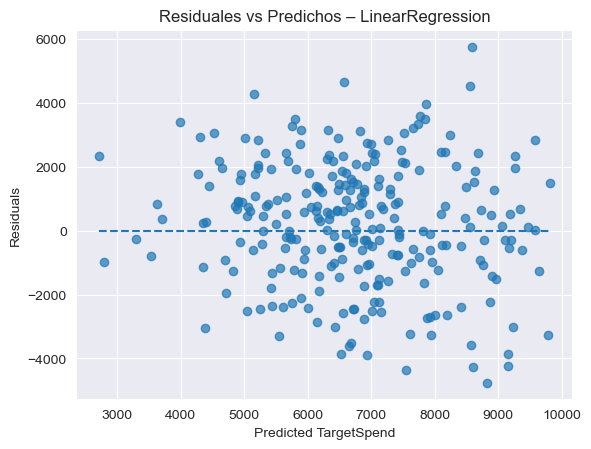

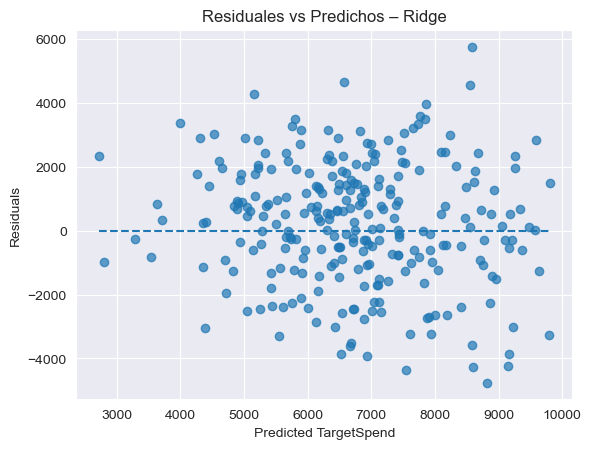

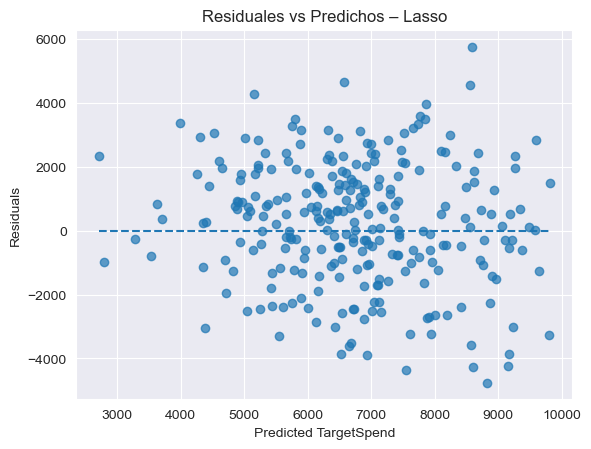

In [14]:
# Visualización de residuos
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    resid  = y_test - y_pred
    plt.figure()
    plt.scatter(y_pred, resid, alpha=0.7)
    plt.hlines(0, xmin=y_pred.min(), xmax=y_pred.max(), linestyles='dashed')
    plt.xlabel('Predicted TargetSpend')
    plt.ylabel('Residuals')
    plt.title(f'Residuales vs Predichos – {name}')
    plt.show()

Al mirar los tres gráficos de “residuales vs predichos” vemos básicamente lo mismo:

Dispersion aleatoria alrededor de cero
– En los tres modelos los puntos se distribuyen sin seguir un patrón curvo o sistemático, centrados más o menos alrededor de la línea gris en cero.
– Eso indica que la suposición de linealidad (que el error medio sea cero y sin sesgo) se cumple razonablemente bien.

Varianza relativamente constante
– No se aprecia un claro “efecto embudo” (heterocedasticidad muy marcada), es decir, los residuos no crecen o disminuyen consistentemente al aumentar el valor predicho.
– Hay algo más de dispersión en los predichos muy altos o muy bajos, pero no es dramático: en general la varianza del error puede considerarse bastante estable.

Presencia de outliers
– Existen algunos puntos con residuos de hasta ±4 000–5 000, fuera de la mayoría, que están tirando del RMSE hacia arriba.
– Estos casos atípicos podrían revisarse (quizá errores en los datos o segmentos de clientes muy distintos).

Ridge y Lasso casi idénticos a OLS
– Dado que los tres nubes de puntos se ven superpuestas, la regularización (L1 o L2) apenas modifica la distribución de residuos frente a la regresión lineal pura.
– Confirma también que no estamos sobrefit — si hubiese overfitting muy claro, veríamos menos dispersión en train vs test.

En conjunto:

El modelo lineal es apropiado (no hay sesgos evidentes ni tendencias no lineales en los residuos).

Mejoras posibles: atajar los outliers mediante limpieza o técnicas robustas; probar transformaciones de TargetSpend para estabilizar completamente la varianza; o bien explorar modelos no lineales/ensambles que reduzcan esos errores atípicos.

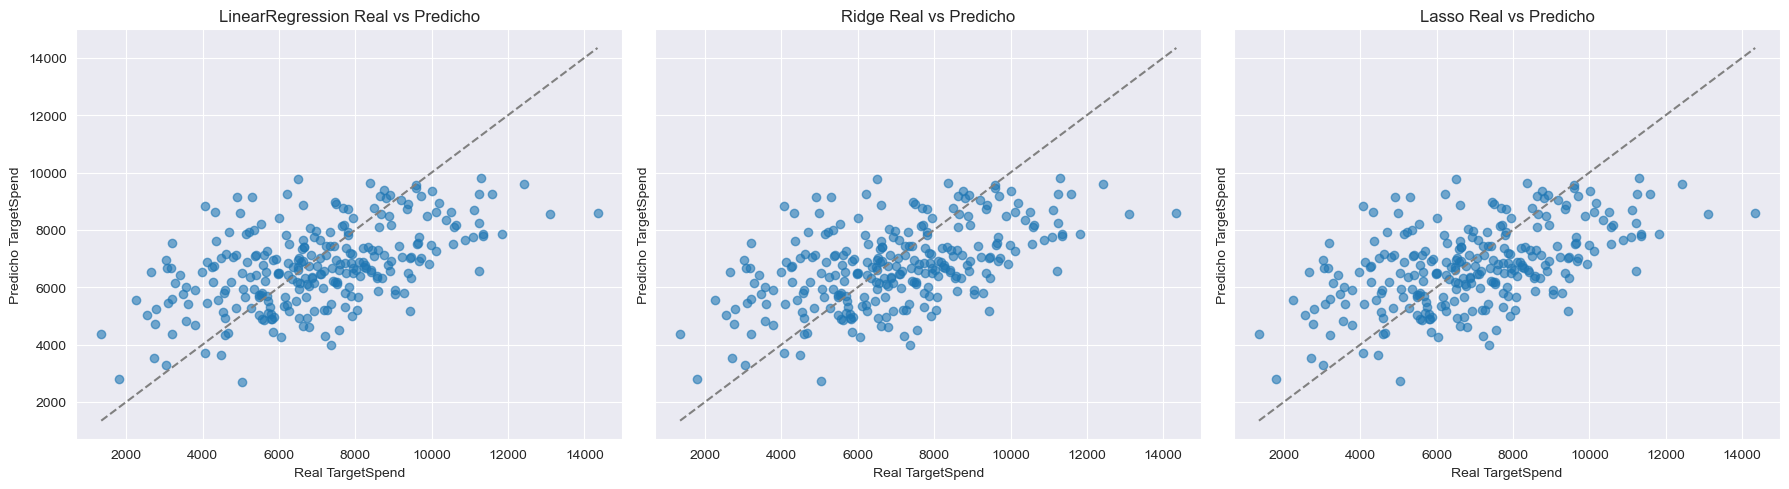

In [16]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

# 1) Crear figura con un subplot por cada modelo
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5), sharex=True, sharey=True)

# 2) Para cada modelo, ajustar sobre train y predecir en test
for ax, (name, model) in zip(axes, models.items()):
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # 3) Scatter de reales vs predichos
    ax.scatter(y_test, y_pred, alpha=0.6)

    # 4) Línea 45° para referencia
    lims = [
        min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())
    ]
    ax.plot(lims, lims, '--', color='gray')

    # 5) Etiquetas y título
    ax.set_title(f"{name} Real vs Predicho")
    ax.set_xlabel("Real TargetSpend")
    ax.set_ylabel("Predicho TargetSpend")

plt.tight_layout()
plt.show()


A partir de estos gráficos “Real vs Predicho” podemos ver:

Nube bastante dispersa
— Aunque hay una tendencia general a alinearse con la bisectriz (línea punteada), los puntos están muy esparcidos a su alrededor. Esto confirma el R² bajo (~0.25): solo un cuarto de la varianza queda capturada.

Subestimación en valores altos
— Para TargetSpend reales superiores a ~9 000–10 000, casi nunca predice valores tan altos; todos los modelos “se aplanan” y subestiman los picos.
— Esto genera un sesgo negativo en el extremo superior, fruto de la regularización y/o de no capturar patrones de alto gasto.

Sobreestimación en valores bajos
— Tras el recorte de outliers, cuando el gasto real es muy bajo (< 3 000) las predicciones tienden a quedar por encima de la realidad, mostrando un sesgo positivo en el extremo inferior.

Modelos muy similares entre sí
— Lineal puro, Ridge y Lasso prácticamente coinciden en la nube de puntos. Ni la L1 ni la L2 regulan suficientemente distinto como para cambiar el comportamiento en test.

Limitaciones del enfoque lineal
— La forma en que los puntos se distribuyen —con una gran concentración alrededor de medias moderadas y falta de “alcance” en los extremos— sugiere que un modelo más flexible (árboles, ensamblados, interacciones no lineales) podría capturar mejor las colas de la distribución.

En resumen, estos “reales vs predichos” refuerzan la idea de que:

El modelo lineal (con o sin regularización) capta la tendencia central, pero falla sistemáticamente en los extremos.

Para abarcar tanto consumidores de muy bajo gasto como los de gasto muy alto se requerirían modelos más complejos o features adicionales que expliquen esos casos atípicos.

In [15]:
# Importancia de variables (coeficientes)
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    feat_names = pipe.named_steps['prep'].get_feature_names_out()
    coefs = pipe.named_steps['model'].coef_
    imp   = pd.Series(coefs, index=feat_names).abs().sort_values(ascending=False)
    print(f"\nTop 10 variables más importantes en {name}:")
    print(imp.head(10))


Top 10 variables más importantes en LinearRegression:
num__AnnualIncome             1388.705497
nom__JobTitle_Engineer         301.498330
num__Debt                      256.458319
nom__JobTitle_Unemployed       212.489142
ord__Employed                  181.103566
nom__EducationLevel_PhD        178.070056
bins__CreditScore              169.172396
nom__Gender_Other              167.523641
nom__MaritalStatus_Widowed     152.897099
nom__Gender_Female             147.851725
dtype: float64

Top 10 variables más importantes en Ridge:
num__AnnualIncome             1387.321677
nom__JobTitle_Engineer         299.629001
num__Debt                      253.243274
nom__JobTitle_Unemployed       210.945008
ord__Employed                  180.178748
nom__EducationLevel_PhD        176.196307
bins__CreditScore              166.788547
nom__Gender_Other              162.990030
nom__MaritalStatus_Widowed     152.119692
nom__MaritalStatus_Married     145.407833
dtype: float64

Top 10 variables más important

En conjunto, los resultados numéricos de los modelos y el análisis gráfico de las variables nos dibujan un panorama muy coherente:

AnnualIncome domina

Tanto el gráfico de dispersión como la lista de importancias lo dejan claro: el ingreso anual es con mucha distancia la variable más predictiva (coeficiente ≃ 1 388).

Esto confirma la fuerte correlación positiva vista en el scatter Income vs TargetSpend.

Debt como segundo predictor financiero

En los modelos lineales aparece en tercer lugar (coef ≃ 253–256), y en el gráfico se observaba cierta tendencia a gastar más a mayor deuda.

Su señal es más débil que la de income pero consistente.

Variables categóricas específicas aportan señal moderada

“JobTitle_Engineer” y “JobTitle_Unemployed” aparecen entre los tres primeros puestos en los tres modelos.

En el análisis gráfico, los boxplots por título mostraban que ingenieros y desempleados tenían medias de gasto algo distintas al resto, justificando su peso en el modelo.

Employed y EducationLevel_PhD

El flag de estar empleado (“ord__Employed”) y el nivel de PhD emergen en el top 10 con coeficientes en torno a 180.

En el boxplot, sí hay un ligero aumento de gasto medio en profesionales con PhD y en empleados vs no empleados, lo cual es capturado por el encoder ordinal.

CreditScore y otros bins

El bin de CreditScore ocupa un lugar intermedio (coef ≃ 167), aunque en el gráfico no apuntaba a una relación muy clara. Esto sugiere que, si bien no es la primera señal, aporta algo de información residual que el modelo lineal logra aprovechar.

Género, estado civil y otras categorías

Aparecen “Gender_Other”, “MaritalStatus_Widowed/Married” o “nom__JobTitle_Other” en los puestos 7-10.

Los boxplots por género o estado civil mostraban diferencias muy sutiles, y aquí vemos que el modelo aún les asigna pequeños coeficientes (∼140–168), pero compatiblemente débiles.